Load the Real dataset

In [1]:
from sklearn.datasets import fetch_california_housing

# Download the California Housing dataset
housing = fetch_california_housing(as_frame=True)

# Get the complete dataset as a pandas DataFrame
df = housing.frame

print("Dataset loaded successfully!")

Dataset loaded successfully!


Look at the data

In [2]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Save a CSV

In [3]:
df.to_csv("california_housing.csv", index=False)
print("CSV created!")

CSV created!


In [ ]:
Check dataset information

In [4]:
print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Rows and Columns: (20640, 9)

Column Names:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

Missing Values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


Select X and y

In [5]:
# X = Input/Feature
X = df[["MedInc"]]

# y = Output/Target
y = df["MedHouseVal"]

print(X.head())
print()
print(y.head())

   MedInc
0  8.3252
1  8.3014
2  7.2574
3  5.6431
4  3.8462

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64


Plot the REAL data before training

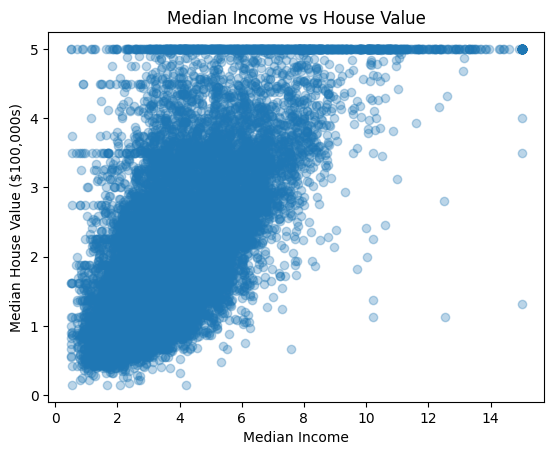

In [6]:
import matplotlib.pyplot as plt

plt.scatter(X, y, alpha=0.3)

plt.xlabel("Median Income")
plt.ylabel("Median House Value ($100,000s)")
plt.title("Median Income vs House Value")

plt.show()

Split training and testing data

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 16512
Testing samples: 4128


Train Linear Regression

In [8]:
from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


Let the model predict TEST data

In [9]:
y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[1.14958917 1.50606882 1.90393718 2.85059383 2.00663318 2.42165249
 2.57647226 1.99229181 2.45893168 3.84677436]


Compare actual vs predicted

In [10]:
comparison = X_test.copy()

comparison["Actual Price"] = y_test
comparison["Predicted Price"] = y_pred

comparison.head(10)

,MedInc,Actual Price,Predicted Price
20046,1.6812,0.47700,1.149589
3024,2.5313,0.45800,1.506069
15663,3.4801,5.00001,1.903937
20484,5.7376,2.18600,2.850594
9814,3.7250,2.78000,2.006633
13311,4.7147,1.58700,2.421652
7113,5.0839,1.98200,2.576472
7668,3.6908,1.57500,1.992292
18246,4.8036,3.40000,2.458932
5723,8.1132,4.46600,3.846774


Draw the Linear Regression line

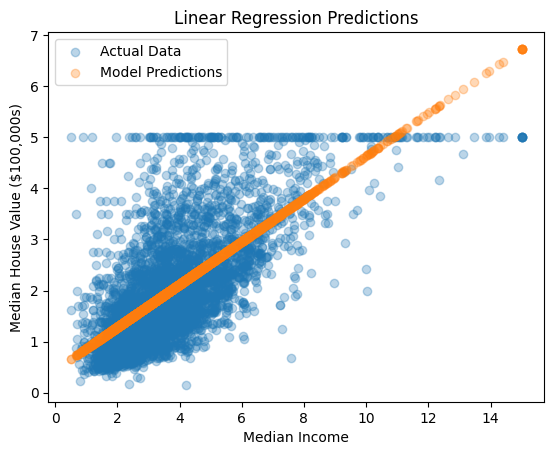

In [11]:
plt.scatter(X_test, y_test, alpha=0.3, label="Actual Data")

plt.scatter(
    X_test,
    y_pred,
    alpha=0.3,
    label="Model Predictions"
)

plt.xlabel("Median Income")
plt.ylabel("Median House Value ($100,000s)")
plt.title("Linear Regression Predictions")

plt.legend()
plt.show()

Check model performance

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Absolute Error: 0.629908653009376
Mean Squared Error: 0.7091157771765549
R² Score: 0.45885918903846656


Make OUR OWN prediction

In [13]:
# Enter a new median income value
income = [[5.0]]

# Make prediction
predicted_price = model.predict(income)

# The dataset stores house values in units of $100,000
price_dollars = predicted_price[0] * 100000

# Display results
print("Median Income:", income[0][0])
print("Predicted House Value (dataset units):", predicted_price[0])
print("Predicted House Value: $", round(price_dollars, 2))

Median Income: 5.0
Predicted House Value (dataset units): 2.5412897613814236
Predicted House Value: $ 254128.98


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
